In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'

### create map from fit parameters


In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'


In [3]:
# import shutil
# # Create a new folder for missing files
# missing_files_dir = os.path.join(map_path, 'missing_ting_fits')
# os.makedirs(missing_files_dir, exist_ok=True)
# print(f"Created directory: {missing_files_dir}")

# # Copy the missing files
# copied_count = 0
# error_count = 0

# for filepath in missing_files:
#     try:
#         if pd.notna(filepath) and os.path.exists(filepath):
#             # Get the filename from the full path
#             filename = os.path.basename(filepath)
            
#             # Create the destination path
#             dest_path = os.path.join(missing_files_dir, filename)
            
#             # Copy the file
#             shutil.copy2(filepath, dest_path)
#             # Also copy the .tdms_index file if it exists
#             index_filepath = filepath + "_index"
#             if os.path.exists(index_filepath):
#                 index_dest_path = dest_path + "_index"
#                 shutil.copy2(index_filepath, index_dest_path)
#             copied_count += 1
#         else:
#             print(f"File not found or invalid: {filepath}")
#             error_count += 1
#     except Exception as e:
#         print(f"Error copying {filepath}: {e}")
#         error_count += 1

# print(f"\nCopy complete:")
# print(f"  Successfully copied: {copied_count} files")
# print(f"  Errors: {error_count} files")
# print(f"  Destination: {missing_files_dir}")

In [4]:
path_ting = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/w_felix/ting_changed_params_wFelix_ting_results.csv'
path_ting_stiff = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/results/w_felix/ting_stiff_ting_results.csv'
map_path = '/Users/evillz/Data/article/2025_30_5/psnex_map___2025.05.30_17.44.50.71/'

map_name = os.path.basename(map_path.strip('/'))  

In [5]:
df_dict_tdms, map_x_pix, map_y_pix, params = maps.load_map_file_square_tdms(map_path)

# of files analyzed: 1024, closest shape: 32 x 32
 map metadata: map_x_step: 0.143, map_y_step: 0.143, map_x_init: 0.0, map_y_init: 0.0
 x_sens (um/V): 5.685, y_sens (um/V): 3.96, z_sens (um/V): 6.0, z_setpoint_trig (V): 7.60257


Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 14.18737800000001, zmin: 0.0
y_sens_um: 3.96, x_sens_um: 5.685


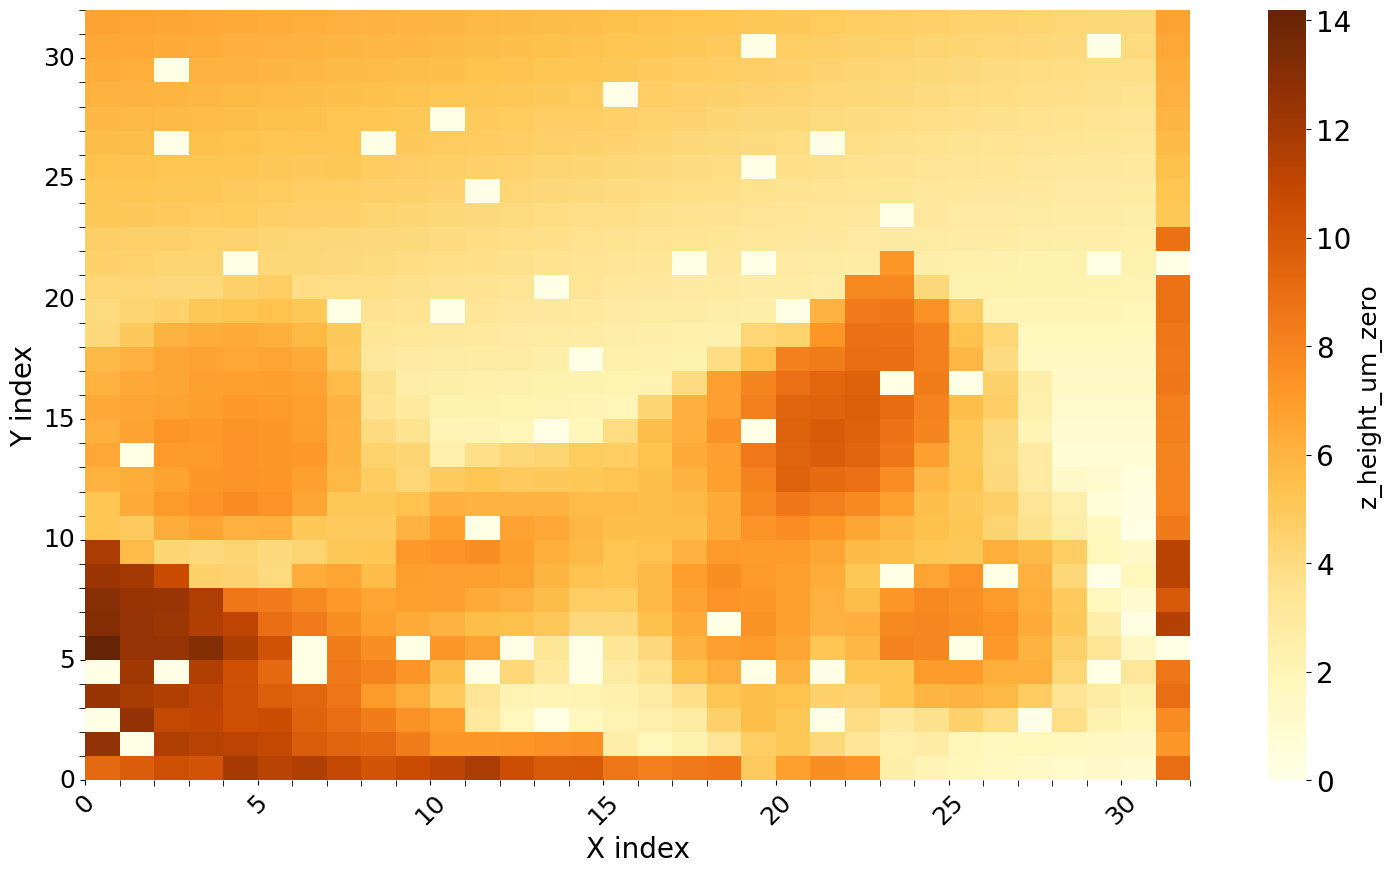

In [6]:
_ = maps.create_heatmap(df_dict_tdms, params=params)

In [7]:
df_ting = pd.read_csv(path_ting)   
df_ting_stiff = pd.read_csv(path_ting_stiff)    

df_ting_merged = pd.merge(df_ting, df_ting_stiff, on=['file_id','file_path'], suffixes=('_old', '_stiff'))
df_final_ting = pd.merge(df_dict_tdms, df_ting_merged, on=['file_id'], how='left')

In [8]:
# Filter columns containing 'ting' AND 'E0' (both must be present)
df_final_ting.filter(regex='ting.*E0|E0.*ting').columns

Index(['ting_E0_old', 'ting_E0_stiff'], dtype='object')

In [9]:
# If ting_E0_old is 0 or NaN, use ting_E0_stiff; else use ting_E0_old
df_final_ting['ting_E0_mixed'] = np.where(
    (df_final_ting['ting_E0_old'] == 0)| np.isnan(df_final_ting['ting_E0_old']),
    df_final_ting['ting_E0_stiff'],
    df_final_ting['ting_E0_old']
)

df_final_ting['betaE_mixed'] = np.where(
    (df_final_ting['ting_betaE_old'] == 0)| np.isnan(df_final_ting['ting_betaE_old']),
    df_final_ting['ting_betaE_stiff'],
    df_final_ting['ting_betaE_old']
)

# Create numeric indicator (0 = old, 1 = stiff)
df_final_ting['E0_source_numeric'] = np.where(
    (df_final_ting['ting_E0_old'] == 0) | np.isnan(df_final_ting['ting_E0_old']),
    1,  # stiff
    0   # old
)



In [10]:
df_final_ting.filter(like = 'height').columns

Index(['z_height_v', 'z_height_um', 'z_height_um_zero',
       'hertz_sample_height_old', 'hertz_sample_height_stiff'],
      dtype='object')

In [11]:
df_final_ting.filter(like = 'betaE').columns

Index(['ting_betaE_old', 'ting_betaE_stiff', 'betaE_mixed'], dtype='object')

In [12]:
csv_file_path = '/Users/evillz/Data/article/csv_maps_article'
map_file_path = '/Users/evillz/Data/article/maps_svg'


Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: -0.3010299956639812, zmin: -1.9999999999994529
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/maps_svg/ting_betaE_old_psnex_map___2025.05.30_17.44.50.71.svg
Saving CSV for ting_betaE_old_psnex_map___2025.05.30_17.44.50.71.csv
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: -0.3010299956639812, zmin: -1.9999999999998568
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/maps_svg/ting_betaE_stiff_psnex_map___2025.05.30_17.44.50.71.svg
Saving CSV for ting_betaE_stiff_psnex_map___2025.05.30_17.44.50.71.csv
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 0.5, zmin: 0.0
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/maps_svg/betaE_mixed_psnex_map___2025.05.30_17.44.50.71.svg
Saving CSV for betaE_mixed_psnex_map___2025.05.30_17.44.50.71.csv


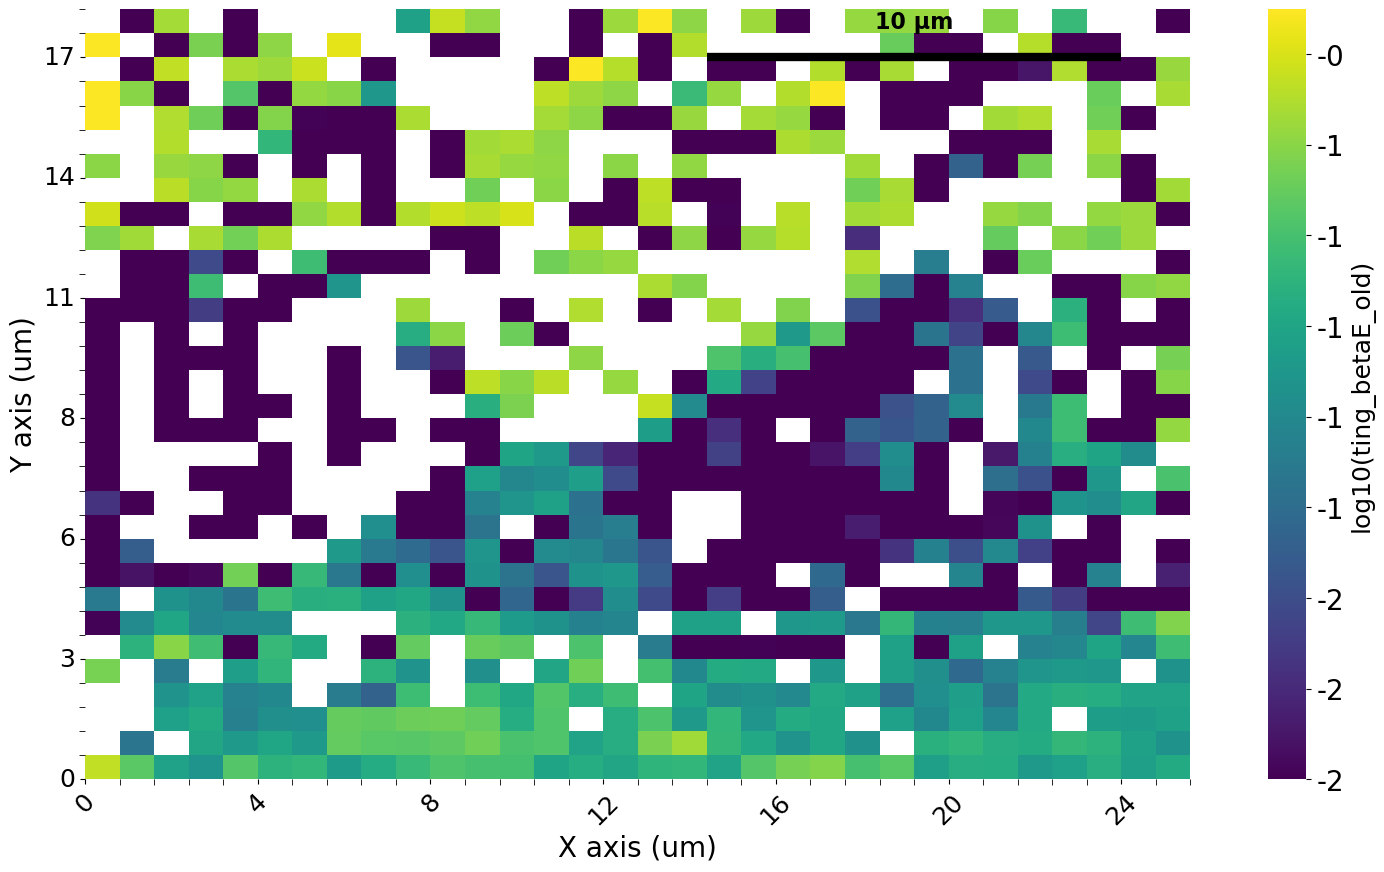

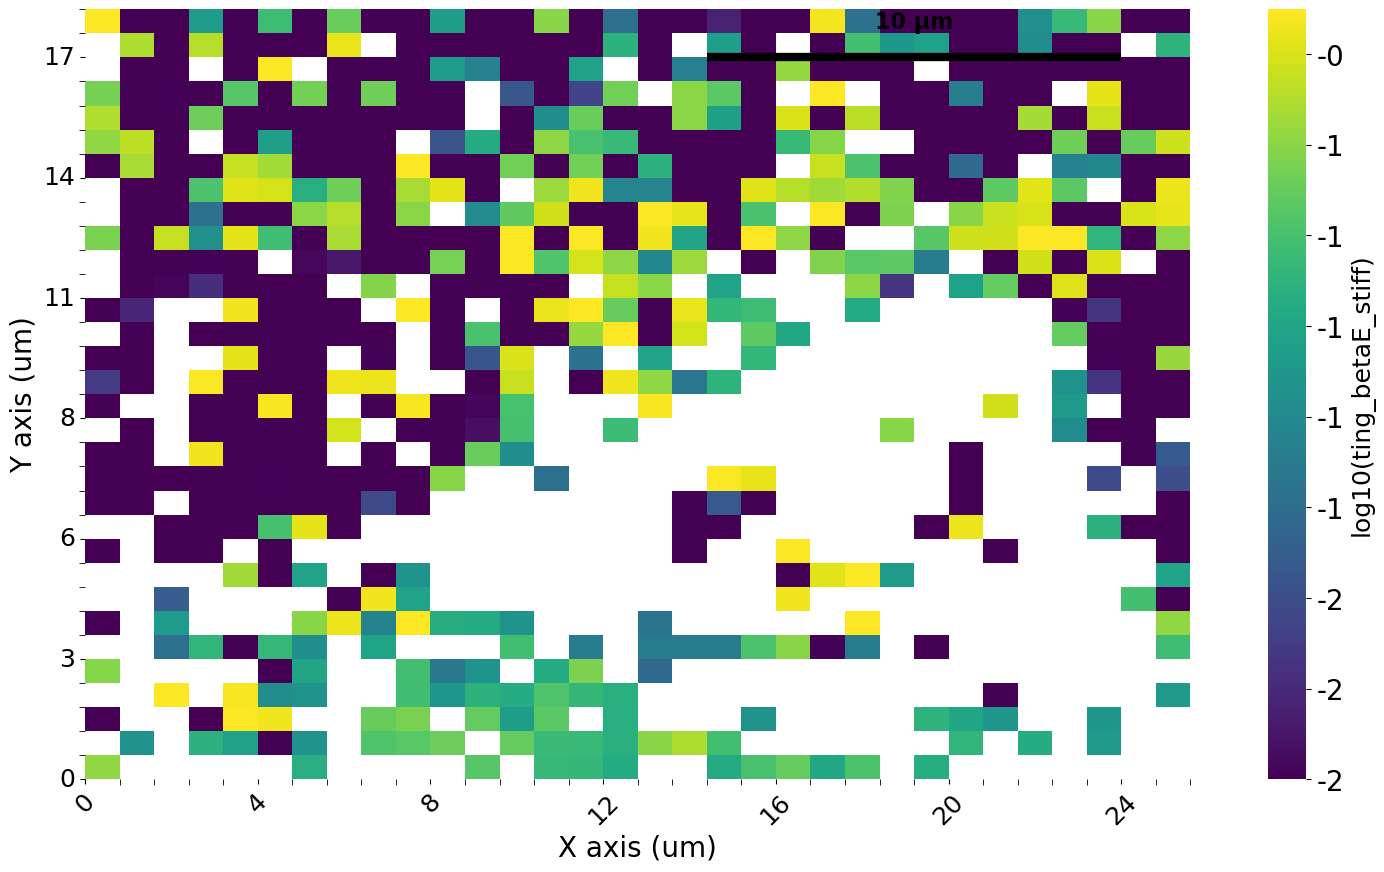

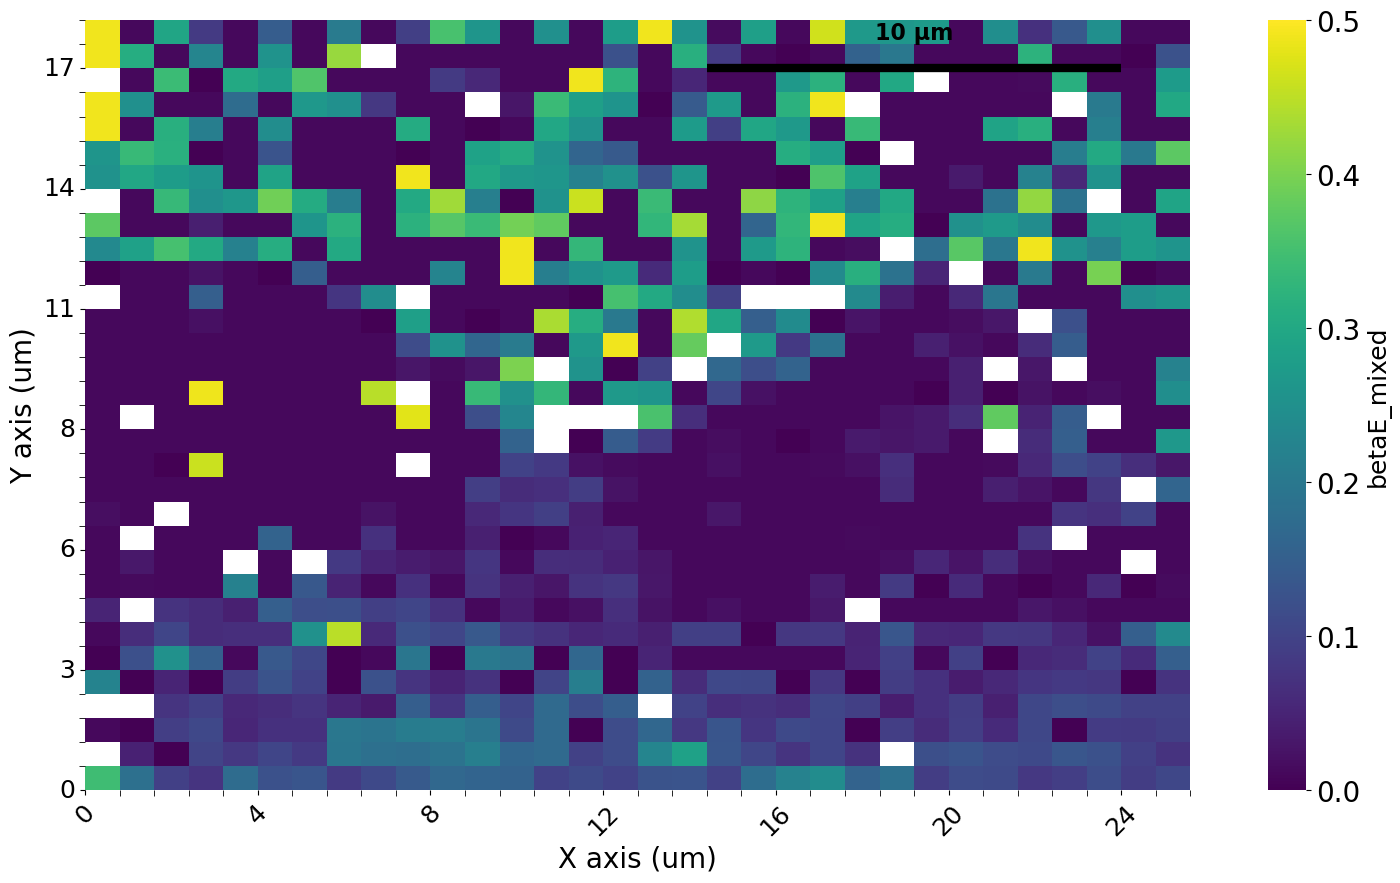

In [13]:

keys_list = ['ting_betaE_old', 'ting_betaE_stiff', 'betaE_mixed']
logscale = [True, True, False]
for key_combined, logscale_value in zip(keys_list, logscale):
    df_temp, _ , _ = maps.create_heatmap(df_final_ting, value_key=key_combined, annot=False,
                            save_svg=True, svg_path=os.path.join(map_file_path, f'{key_combined}_{map_name}.svg'),
                            cmap='viridis', nan=True, lastColFirst=False, logscale=logscale_value, scale_axis=True,
                            zmax = 0.5,)

    # save csv file for each map
    print (f'Saving CSV for {key_combined}_{map_name}.csv')

    # df_temp.to_csv(os.path.join(csv_file_path, f'{key_combined}_{map_name}.csv'), index=False)
    # # save corresponding dataframe as csv file with all rows and columsn from df_temp dataframe

                            

In [14]:
#print log10 of x
x = 1331031.89
import math
print(math.log10(x))

# print inverse of log10 of x
print(10**5) 

6.124188460797828
100000


Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 5.0, zmin: 1.4272730766394324
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/article/maps_svg/ting_E0_mixed_psnex_map___2025.05.30_17.44.50.71.svg


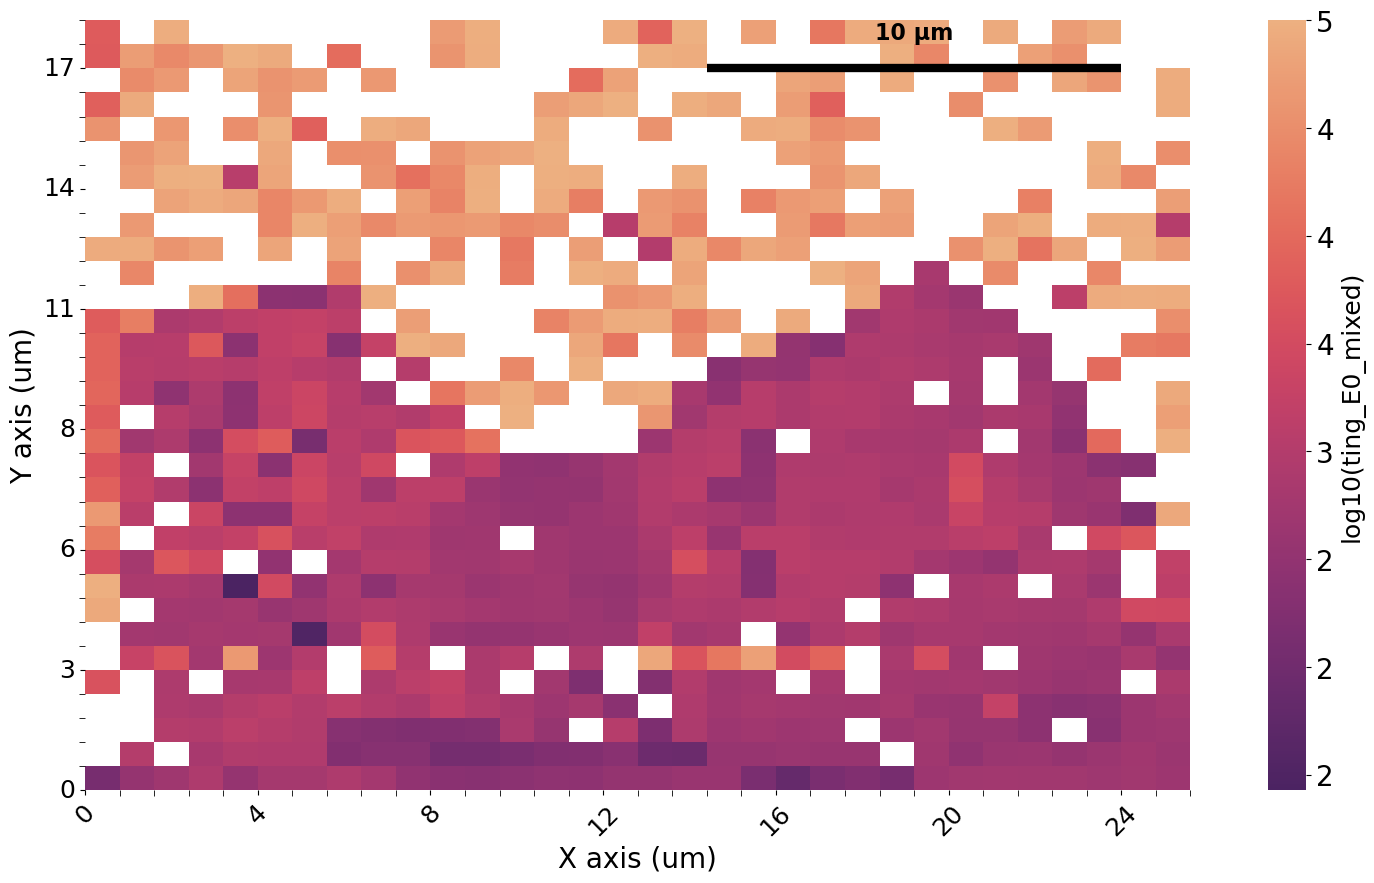

In [ ]:
# keys_list = ['ting_E0_mixed', 'ting_E0_old', 'ting_E0_stiff', 'z_height_um_zero', 'betaE_mixed']
# logscale = [True, True, True, False, True]

keys_list = ['ting_E0_mixed']
logscale = [True]

for key_combined, logscale_value in zip(keys_list, logscale):
    df_temp, _ , _ = maps.create_heatmap(df_final_ting, value_key=key_combined, annot=False,
                            save_svg=False, svg_path=os.path.join(map_file_path, f'{key_combined}_{map_name}.svg'),
                            cmap='flare_r', nan=True, lastColFirst=False, logscale=logscale_value, scale_axis=True, zmax = 100000)
    
    # save csv file for each map
    # print (f'Saving CSV for {key_combined}_{map_name}.csv')
    # df_temp.to_csv(os.path.join(csv_file_path, f'{key_combined}_{map_name}.csv'), index=False)
    # save corresponding dataframe as csv file with all rows and columsn from df_temp dataframe
    # df_temp.to_csv(os.path.join(csv_file_path, f'{key_combined}_{map_name}_full.csv'), index=False)

    # save svg file for each map
    
  


In [16]:
z_height_um_zero = df_final_ting['z_height_um_zero']    

Text(0, 0.5, 'Frequency')

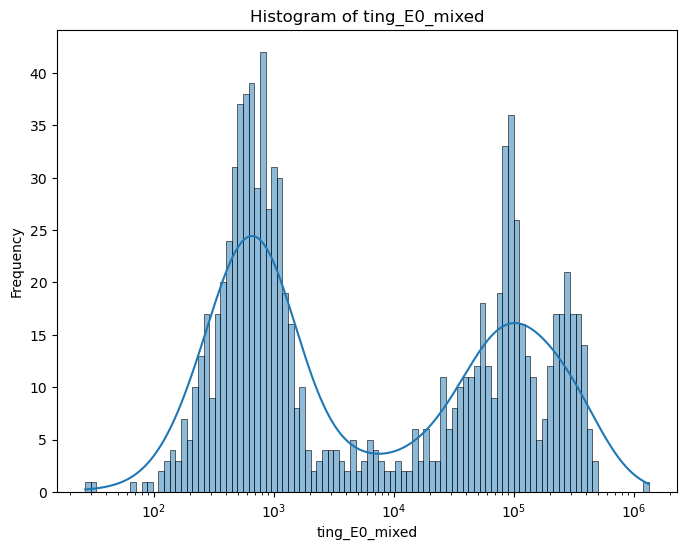

In [17]:
# plot histogram of ting_E0_mixed using seaborn. make x axis in logscale,
plt.figure(figsize=(8,6))
sns.histplot(df_final_ting['ting_E0_mixed'].dropna(), bins=100, kde=True, log_scale=True)
plt.title('Histogram of ting_E0_mixed')
plt.xlabel('ting_E0_mixed')
plt.ylabel('Frequency')         

Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 1, zmin: 0
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Users/evillz/Data/CTC44/2025_12_03/svg_maps/E0_source_mask_psnex_map___2025.05.30_17.44.50.71.svg


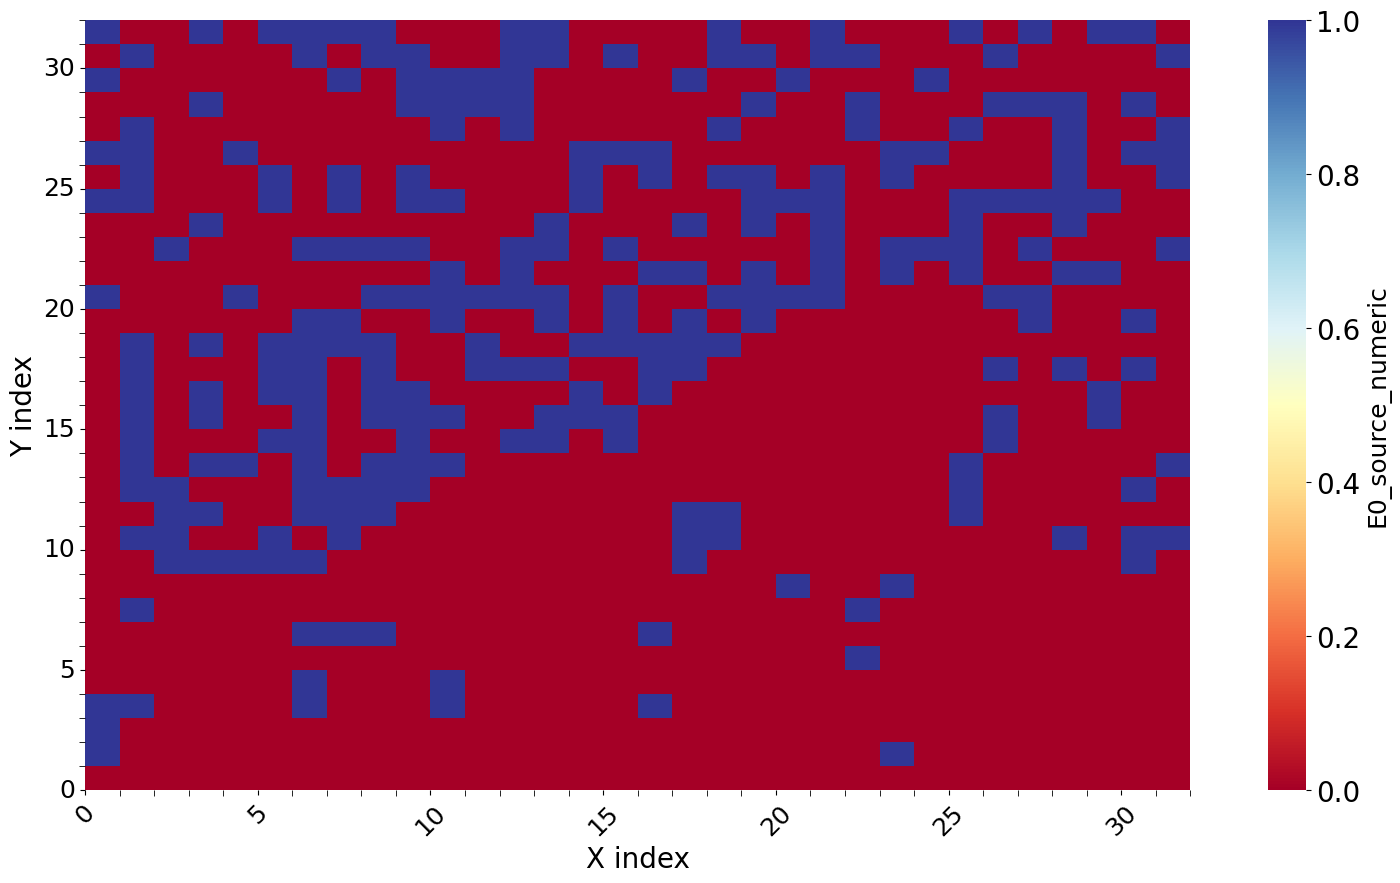

In [18]:

# Plot with binary colormap
_ = maps.create_heatmap(
    df_final_ting,
    value_key='E0_source_numeric', 
    annot=False,
    save_svg=True, 
    svg_path=os.path.join(svg_dir, f'E0_source_mask_{map_name}.svg'),
    cmap='RdYlBu',  # Red = old, Blue = stiff
    nan=False, 
    lastColFirst=False, 
    logscale=False,
    zmin=0,
    zmax=1
)

In [19]:
from pyfmreader import loadfile
from pyfmreader.ps_nex.parseTDMS import get_channel_names, parse_tdms
from pyfmreader.ps_nex.parsepsnexheader import parsePSNEXheader



In [20]:
# get the filepath from df_ting, Open force curve, then calculate the force curve total time

for index, row in df_final_ting.iterrows():
    #print filename
    filepath = row['file_path']
    channels = get_channel_names(filepath)

    channel_data_deflection, channel_data_piezo, channel_time = parse_tdms(filepath, deflectionChannel=channels[0][0], zDisplacement=channels[0][1])


    file = loadfile(filepath)
    
    filemetadata = file.filemetadata
    file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
    K = filemetadata['spring_const_Nbym'] #N/m
    height_channel_key = filemetadata['height_channel_key']
    deflection_channel_key = filemetadata['deflection_chanel_key']

    defl_sens = file_deflection_sensitivity / 1e9 #m/V

    # Select curve by index
    curve_idx = 0
    try : 
        force_curve = file.getcurve(curve_idx, bool_correct_overshoot=True)
    except IndexError:
        print(f"Curve index {curve_idx} does not exist in the file.")
        force_curve = None  

    # Preprocess curve to get the segments
    try:
        force_curve.preprocess_force_curve(defl_sens, height_channel_key)
    except Exception as e:
        print(f"Error occurred during preprocessing: {e}")

    # Get segments and indentation
    segs = force_curve.get_segments()
    # these metadata is only available after getting segments
    final_nb_points = filemetadata['final_nb_points']
    relative_SR = filemetadata['relative_sr']
    # save file size
    file_size = filemetadata['file_size_bytes']
    print(f'file_size: {file_size} bytes')

    # Get zheight and vdeflection, for now only get retract
    zmin_app = 0
    show_plots = False
    for segid, segment in segs:
        if segment.segment_type in ('Approach', 'App'):
            zmin_app = segment.zheight.min()
            app_piezo = segment.zheight
            app_deflection = segment.vdeflection * K  # Convert to N
            relative_SR_app = relative_SR[segid-1]
            vel_app_um_s = segment.velocity * 1e6  # Convert nm/s to um/s
            if show_plots:
                plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'g-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
        elif segment.segment_type in ('Retract', 'Ret'):
            ret_piezo = segment.zheight
            ret_deflection = segment.vdeflection * K  # Convert to N
            ret_velocity = segment.velocity   # Convert nm/s to um/s
            relative_SR_ret = relative_SR[segid-1]
            vel_ret_um_s = segment.velocity * 1e6  # Convert nm/s to um/s
            print (f"Retract velocity: {ret_velocity} m/s" )
            time_ret = np.arange(len(ret_piezo)) * relative_SR_ret  # Assuming relative_SR_ret is in Hz, convert to seconds
            print (f"{len(ret_piezo)}, {len(ret_deflection)}, {len(time_ret )}")
            if show_plots:
                plt.plot(segment.zheight - zmin_app, segment.vdeflection, 'r-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
        elif segment.segment_type in ('Contact', 'Con', 'Pause'):
            con_piezo = segment.zheight
            con_deflection = segment.vdeflection * K  # Convert to N
            con_velocity = segment.velocity   # Convert nm/s to um/s
            relative_SR_con = relative_SR[segid-1]
            if show_plots:
                plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'b-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    if show_plots:
        plt.legend()
        plt.xlabel('displacement (m)')
        plt.ylabel('vdeflection (nm)')

    # depening if there is a value , get length of total force curve: app+ con + ret
    if 'con_piezo' in locals():
        total_length = len(app_piezo) - len(con_piezo) + len(ret_piezo)
        print(f"Total length of the force curve without contact: {total_length}")


    deflection_N = np.concatenate((app_deflection, ret_deflection))
    zheight = np.concatenate((app_piezo, ret_piezo)) 
    time = np.concatenate((np.arange(len(app_piezo)) * relative_SR_app,
                              np.arange(len(ret_piezo)) * relative_SR_ret + (len(app_piezo) * relative_SR_app)
                             ))

    print (len(zheight), len(deflection_N))
    print (f"Total time of force curve: {time[-1]} seconds")
    # put total time in dataframe
    df_final_ting.at[index, 'force_curve_total_time_s'] = time[-1]  
    df_final_ting.at[index, 'file_size_bytes'] = file_size


Correcting overshoot in the approach segment
file_size: 342239 bytes
Retract velocity: 0.00010000307999999998 m/s
15587, 15587, 15587
21089 21089
Total time of force curve: 0.42175999999999997 seconds
Correcting overshoot in the approach segment
file_size: 757800 bytes
Retract velocity: 0.00010000307999999998 m/s
16091, 16091, 16091
47061 47061
Total time of force curve: 0.9411999999999999 seconds
Correcting overshoot in the approach segment
file_size: 745703 bytes
Retract velocity: 0.00010000307999999998 m/s
16130, 16130, 16130
46305 46305
Total time of force curve: 0.9260799999999999 seconds
Correcting overshoot in the approach segment
file_size: 735946 bytes
Retract velocity: 0.00010000307999999998 m/s
16147, 16147, 16147
45695 45695
Total time of force curve: 0.9138799999999999 seconds
Correcting overshoot in the approach segment
file_size: 782826 bytes
Retract velocity: 0.00010000307999999998 m/s
16130, 16130, 16130
48625 48625
Total time of force curve: 0.9724799999999999 seconds

In [21]:
# # plot deflection and zpos vs time in subplot
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ax1.plot(time, zheight, 'b-', label='Z Height (m)')
# ax1.set_ylabel('Z Height (m)')
# ax1.legend()
# ax1.grid()

# ax2.plot(time, deflection_N, 'r-', label='Deflection (N)')
# ax2.set_xlabel('Time (s)')
# ax2.set_ylabel('Deflection (N)')
# ax2.legend()
# ax2.grid()

# plt.tight_layout()
# plt.show()

/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_115/1107391990.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


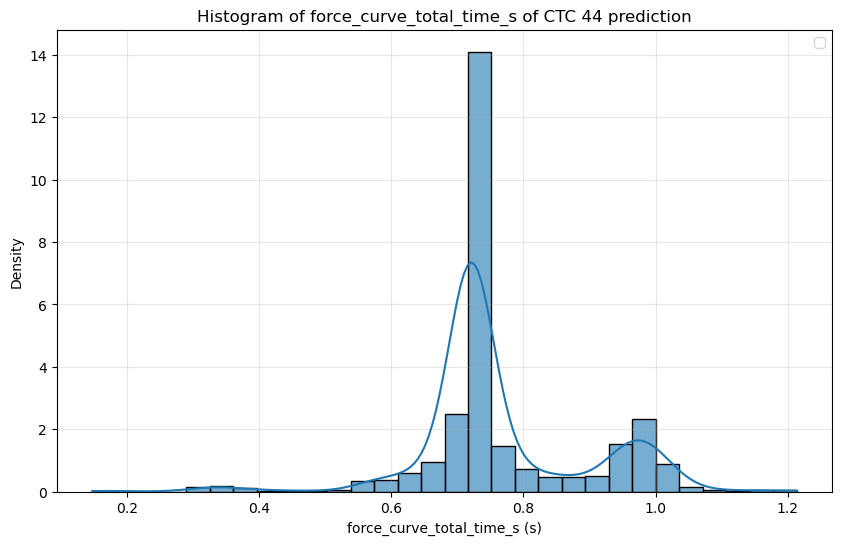

Component 1 - Mean: 0.7706s, Std: 0.1119s, Weight: 95.02%
Component 2 - Mean: 0.6671s, Std: 0.2870s, Weight: 4.98%


In [22]:
from scipy import stats
from sklearn.mixture import GaussianMixture

# plot histogram of force_curve_total_time_s and plot the bimodal distribution
# Create histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_final_ting['force_curve_total_time_s'].dropna(), bins=30, kde=True, stat='density', alpha=0.6)

# Fit a Gaussian Mixture Model with 2 components for bimodal distribution
data = df_final_ting['force_curve_total_time_s'].dropna().values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data)

# Generate x values for plotting the fitted distributions
x = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)
logprob = gmm.score_samples(x)
responsibilities = gmm.predict_proba(x)
pdf = np.exp(logprob)
pdf_individual = responsibilities * pdf[:, np.newaxis]

# # Plot the overall fitted distribution and individual components
# plt.plot(x, pdf, '-k', linewidth=2, label='GMM fit')
# plt.plot(x, pdf_individual[:, 0], '--', linewidth=2, label=f'Component 1 (μ={gmm.means_[0][0]:.3f})')
# plt.plot(x, pdf_individual[:, 1], '--', linewidth=2, label=f'Component 2 (μ={gmm.means_[1][0]:.3f})')

plt.title('Histogram of force_curve_total_time_s of CTC 44 prediction')
plt.xlabel('force_curve_total_time_s (s)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Component 1 - Mean: {gmm.means_[0][0]:.4f}s, Std: {np.sqrt(gmm.covariances_[0][0][0]):.4f}s, Weight: {gmm.weights_[0]:.2%}")
print(f"Component 2 - Mean: {gmm.means_[1][0]:.4f}s, Std: {np.sqrt(gmm.covariances_[1][0][0]):.4f}s, Weight: {gmm.weights_[1]:.2%}")

In [23]:
# print statistics of force_curve_total_time_s
print("Statistics of force_curve_total_time_s:")
print(f"Mean: {df_final_ting['force_curve_total_time_s'].mean():.4f} s")
print(f"Median: {df_final_ting['force_curve_total_time_s'].median():.4f} s")
print(f"Standard Deviation: {df_final_ting['force_curve_total_time_s'].std():.4f} s")
print(f"Minimum: {df_final_ting['force_curve_total_time_s'].min():.4f} s")
print(f"Maximum: {df_final_ting['force_curve_total_time_s'].max():.4f} s")

Statistics of force_curve_total_time_s:
Mean: 0.7655 s
Median: 0.7221 s
Standard Deviation: 0.1285 s
Minimum: 0.1477 s
Maximum: 1.2136 s


Statistics of file_size_bytes:
Mean: 617239.39 bytes
Median: 582536.00 bytes
Standard Deviation: 102801.98 bytes
Minimum: 122969.00 bytes
Maximum: 975713.00 bytes
Total file size: 602.77 MB


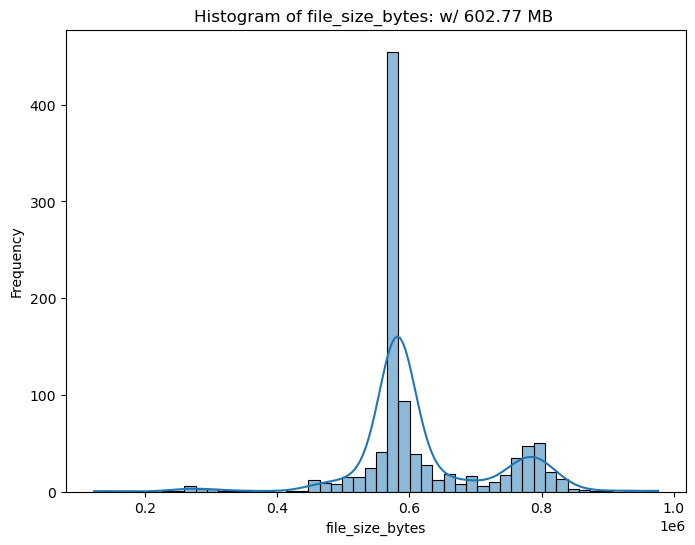

In [24]:
# print statistics of file_size_bytes and plot histogram
print("Statistics of file_size_bytes:")
print(f"Mean: {df_final_ting['file_size_bytes'].mean():.2f} bytes")
print(f"Median: {df_final_ting['file_size_bytes'].median():.2f} bytes")
print(f"Standard Deviation: {df_final_ting['file_size_bytes'].std():.2f} bytes")
print(f"Minimum: {df_final_ting['file_size_bytes'].min():.2f} bytes")
print(f"Maximum: {df_final_ting['file_size_bytes'].max():.2f} bytes")   

# sum file_size_bytes in MB
total_size_mb = df_final_ting['file_size_bytes'].sum() / (1024 * 1024)
print(f"Total file size: {total_size_mb:.2f} MB")
# plot histogram of file_size_bytes
plt.figure(figsize=(8,6))
sns.histplot(df_final_ting['file_size_bytes'].dropna(), bins=50, kde=True)
plt.title(f'Histogram of file_size_bytes: w/ {total_size_mb:.2f} MB ')
plt.xlabel('file_size_bytes')
plt.ylabel('Frequency')         
plt.show()  

Compare with a map file without any fast approach



# of files analyzed: 1024, square root is : 32.0
Using provided DataFrame for heatmap
Map dimensions: 32 x 32
zmax: 14.270874000000006, zmin: 0.0
y_sens_um: 3.96, x_sens_um: 5.685


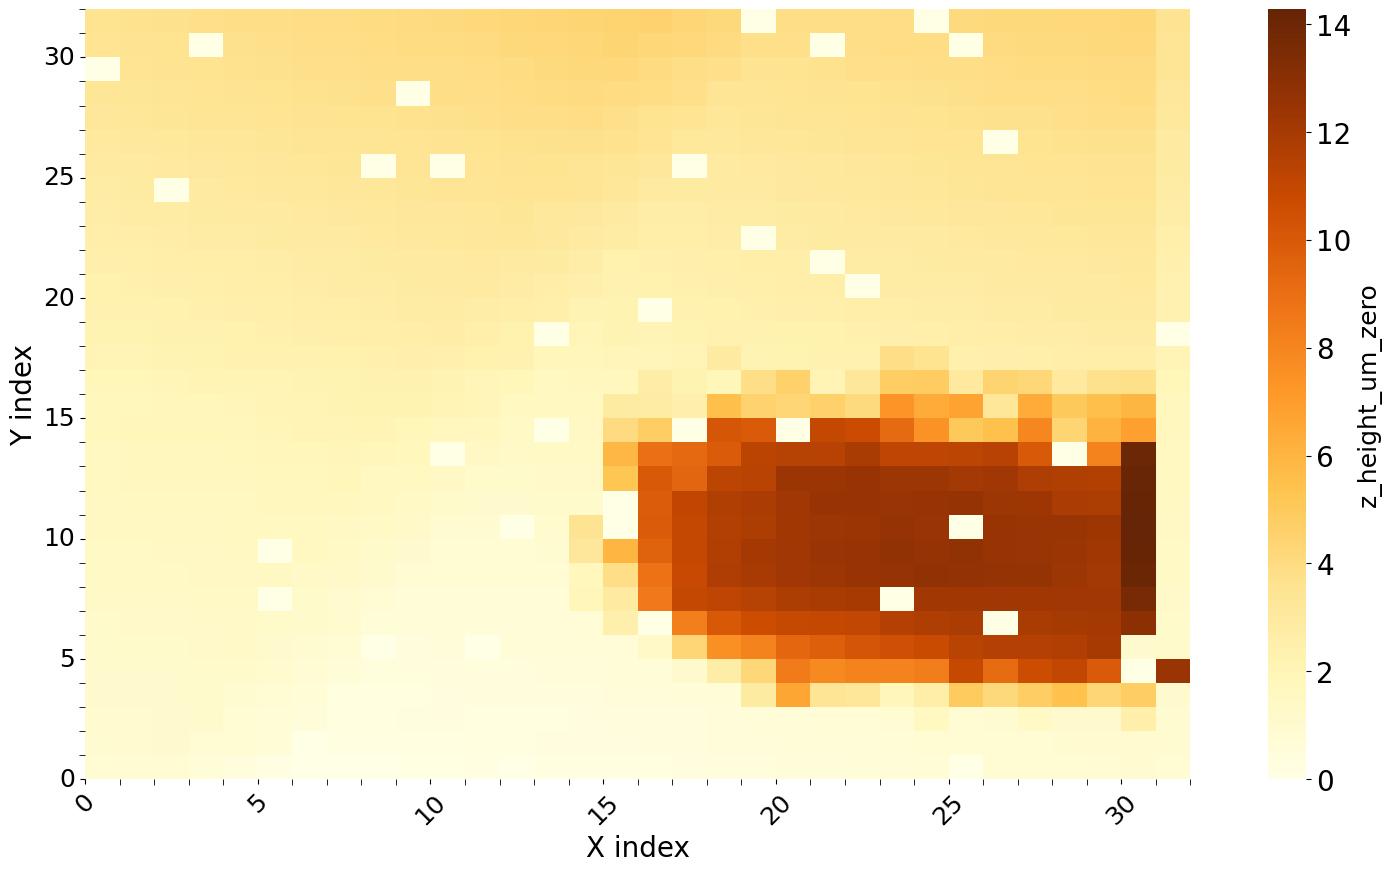

In [25]:
# change df_final_ting to open another file to compare
no_fastApp_algo_map_path = '/Users/evillz/Data/article/psnex_map___2025.03.11_12.07.58.99'

no_fastApp_algo_map_path = '/Users/evillz/Data/psnex_map___2024.11.22_14.48.26.59'

no_fastApp_algo_map_path = '/Users/evillz/Data/THP_LiveCells/2024_07_24/map0_thp1_fixated_cells_2'
df_sorted = maps.load_map_file_square_tdms_v2(no_fastApp_algo_map_path)

df_map = maps.create_heatmap(df_sorted)

In [26]:
# get the filepath from df_ting, Open force curve, then calculate the force curve total time

for index, row in df_sorted.iterrows():
    #print filename
    filepath = row['filepaths']
    channels = get_channel_names(filepath)

    channel_data_deflection, channel_data_piezo, channel_time = parse_tdms(filepath, deflectionChannel=channels[0][0], zDisplacement=channels[0][1])


    file = loadfile(filepath)
    
    filemetadata = file.filemetadata
    file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
    K = filemetadata['spring_const_Nbym'] #N/m
    height_channel_key = filemetadata['height_channel_key']
    deflection_channel_key = filemetadata['deflection_chanel_key']

    defl_sens = file_deflection_sensitivity / 1e9 #m/V

    # Select curve by index
    curve_idx = 0
    try : 
        force_curve = file.getcurve(curve_idx, bool_correct_overshoot=True)
    except IndexError:
        print(f"Curve index {curve_idx} does not exist in the file.")
        force_curve = None  

    # Preprocess curve to get the segments
    try:
        force_curve.preprocess_force_curve(defl_sens, height_channel_key)
    except Exception as e:
        print(f"Error occurred during preprocessing: {e}")

    # Get segments and indentation3
    segs = force_curve.get_segments()
    # these metadata is only available after getting segments
    final_nb_points = filemetadata['final_nb_points']
    relative_SR = filemetadata['relative_sr']
    # save file size
    file_size = filemetadata['file_size_bytes']
    print(f'file_size: {file_size} bytes')

    # Get zheight and vdeflection, for now only get retract
    zmin_app = 0
    show_plots = False
    for segid, segment in segs:
        if segment.segment_type in ('Approach', 'App'):
            zmin_app = segment.zheight.min()
            app_piezo = segment.zheight
            app_deflection = segment.vdeflection * K  # Convert to N
            relative_SR_app = relative_SR[segid-1]
            vel_app_um_s = segment.velocity * 1e6  # Convert nm/s to um/s
            if show_plots:
                plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'g-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
        elif segment.segment_type in ('Retract', 'Ret'):
            ret_piezo = segment.zheight
            ret_deflection = segment.vdeflection * K  # Convert to N
            ret_velocity = segment.velocity   # Convert nm/s to um/s
            relative_SR_ret = relative_SR[segid-1]
            vel_ret_um_s = segment.velocity * 1e6  # Convert nm/s to um/s
            print (f"Retract velocity: {ret_velocity} m/s" )
            time_ret = np.arange(len(ret_piezo)) * relative_SR_ret  # Assuming relative_SR_ret is in Hz, convert to seconds
            print (f"{len(ret_piezo)}, {len(ret_deflection)}, {len(time_ret )}")
            if show_plots:
                plt.plot(segment.zheight - zmin_app, segment.vdeflection, 'r-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
        elif segment.segment_type in ('Contact', 'Con', 'Pause'):
            con_piezo = segment.zheight
            con_deflection = segment.vdeflection * K  # Convert to N
            con_velocity = segment.velocity   # Convert nm/s to um/s
            relative_SR_con = relative_SR[segid-1]
            if show_plots:
                plt.plot(segment.zheight-zmin_app, segment.vdeflection, 'b-', linewidth=1.5, label=f'{segment.segment_type}', alpha=0.7)
    if show_plots:
        plt.legend()
        plt.xlabel('displacement (m)')
        plt.ylabel('vdeflection (nm)')

    # depening if there is a value , get length of total force curve: app+ con + ret
    if 'con_piezo' in locals():
        total_length = len(app_piezo) - len(con_piezo) + len(ret_piezo)
        print(f"Total length of the force curve without contact: {total_length}")


    deflection_N = np.concatenate((app_deflection, ret_deflection))
    zheight = np.concatenate((app_piezo, ret_piezo)) 
    time = np.concatenate((np.arange(len(app_piezo)) * relative_SR_app,
                              np.arange(len(ret_piezo)) * relative_SR_ret + (len(app_piezo) * relative_SR_app)
                             ))

    print (len(zheight), len(deflection_N))
    print (f"Total time of force curve: {time[-1]} seconds")
    # put total time in dataframe
    df_sorted.at[index, 'force_curve_total_time_s'] = time[-1]  
    df_sorted.at[index, 'file_size_bytes'] = file_size


Correcting overshoot in the approach segment
file_size: 62629 bytes
Retract velocity: 1.2503007e-05 m/s
1015, 1015, 1015
3615 3615
Total time of force curve: 0.7227999999999999 seconds
Correcting overshoot in the approach segment
file_size: 62732 bytes
Retract velocity: 1.2503007e-05 m/s
1015, 1015, 1015
3621 3621
Total time of force curve: 0.724 seconds
Correcting overshoot in the approach segment
file_size: 62793 bytes
Retract velocity: 1.2503007e-05 m/s
1021, 1021, 1021
3625 3625
Total time of force curve: 0.7247999999999999 seconds
Correcting overshoot in the approach segment
file_size: 62843 bytes
Retract velocity: 1.2503007e-05 m/s
1021, 1021, 1021
3628 3628
Total time of force curve: 0.7253999999999999 seconds
Correcting overshoot in the approach segment
file_size: 62892 bytes
Retract velocity: 1.2503007e-05 m/s
1021, 1021, 1021
3631 3631
Total time of force curve: 0.7259999999999999 seconds
Correcting overshoot in the approach segment
file_size: 62908 bytes
Retract velocity: 1.

/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_115/4076433444.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


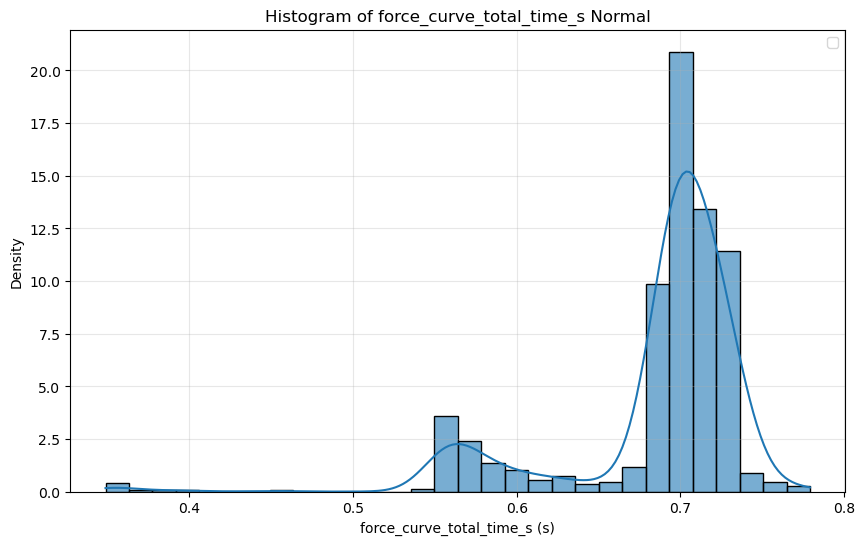

Component 1 - Mean: 0.7076s, Std: 0.0158s, Weight: 81.30%
Component 2 - Mean: 0.5902s, Std: 0.0754s, Weight: 18.70%


In [27]:
from scipy import stats
from sklearn.mixture import GaussianMixture

# plot histogram of force_curve_total_time_s and plot the bimodal distribution
# Create histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_sorted['force_curve_total_time_s'].dropna(), bins=30, kde=True, stat='density', alpha=0.6)

# Fit a Gaussian Mixture Model with 2 components for bimodal distribution
data = df_sorted['force_curve_total_time_s'].dropna().values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data)

# Generate x values for plotting the fitted distributions
x = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)
logprob = gmm.score_samples(x)
responsibilities = gmm.predict_proba(x)
pdf = np.exp(logprob)
pdf_individual = responsibilities * pdf[:, np.newaxis]

# # Plot the overall fitted distribution and individual components
# plt.plot(x, pdf, '-k', linewidth=2, label='GMM fit')
# plt.plot(x, pdf_individual[:, 0], '--', linewidth=2, label=f'Component 1 (μ={gmm.means_[0][0]:.3f})')
# plt.plot(x, pdf_individual[:, 1], '--', linewidth=2, label=f'Component 2 (μ={gmm.means_[1][0]:.3f})')

plt.title('Histogram of force_curve_total_time_s Normal')
plt.xlabel('force_curve_total_time_s (s)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Component 1 - Mean: {gmm.means_[0][0]:.4f}s, Std: {np.sqrt(gmm.covariances_[0][0][0]):.4f}s, Weight: {gmm.weights_[0]:.2%}")
print(f"Component 2 - Mean: {gmm.means_[1][0]:.4f}s, Std: {np.sqrt(gmm.covariances_[1][0][0]):.4f}s, Weight: {gmm.weights_[1]:.2%}")

Statistics of file_size_bytes:
Mean: 59668.78 bytes
Median: 60966.00 bytes
Standard Deviation: 4638.89 bytes
Minimum: 32721.00 bytes
Maximum: 67159.00 bytes
Total file size: 58.27 MB


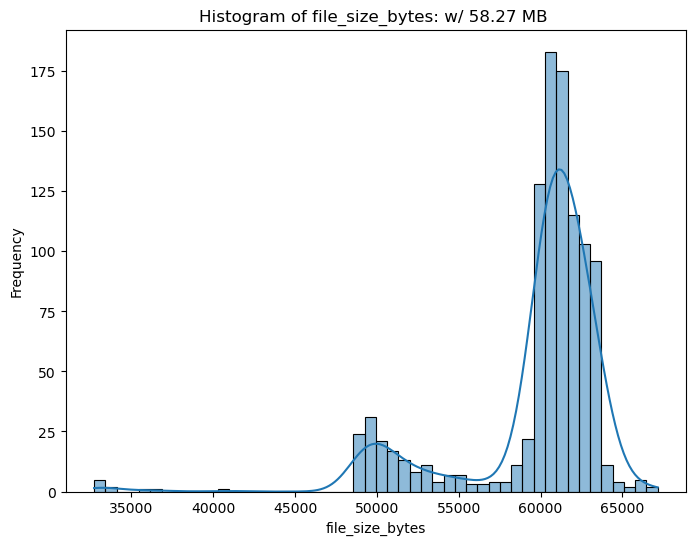

In [28]:
# print statistics of file_size_bytes and plot histogram
print("Statistics of file_size_bytes:")
print(f"Mean: {df_sorted['file_size_bytes'].mean():.2f} bytes")
print(f"Median: {df_sorted['file_size_bytes'].median():.2f} bytes")
print(f"Standard Deviation: {df_sorted['file_size_bytes'].std():.2f} bytes")
print(f"Minimum: {df_sorted['file_size_bytes'].min():.2f} bytes")
print(f"Maximum: {df_sorted['file_size_bytes'].max():.2f} bytes")   

# sum file_size_bytes in MB
total_size_mb = df_sorted['file_size_bytes'].sum() / (1024 * 1024)
print(f"Total file size: {total_size_mb:.2f} MB")
# plot histogram of file_size_bytes
plt.figure(figsize=(8,6))
sns.histplot(df_sorted['file_size_bytes'].dropna(), bins=50, kde=True)
plt.title(f'Histogram of file_size_bytes: w/ {total_size_mb:.2f} MB ')
plt.xlabel('file_size_bytes')
plt.ylabel('Frequency')         
plt.show()  

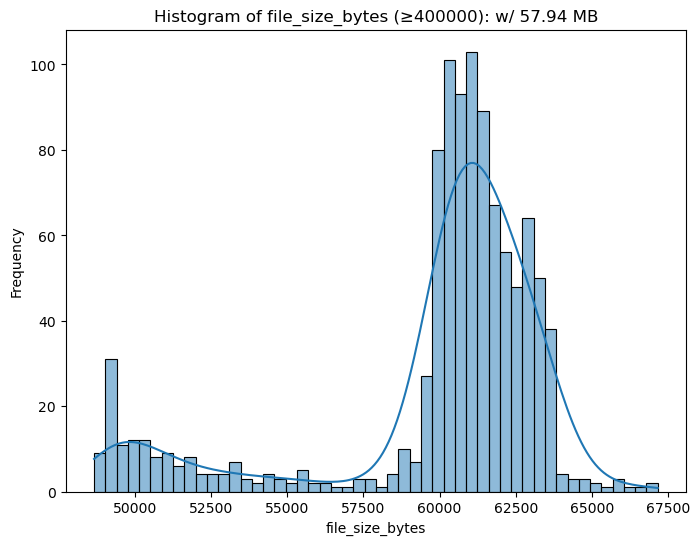

Statistics of file_size_bytes (filtered, ≥400000):
Mean: 59916.20 bytes
Median: 60982.50 bytes
Standard Deviation: 3924.15 bytes
Minimum: 48658.00 bytes
Maximum: 67159.00 bytes
Total file size: 57.94 MB
Number of files: 1014


In [29]:
# Filter df_sorted to keep only rows where file_size_bytes >= 400000
df_sorted_filtered = df_sorted[df_sorted['file_size_bytes'] > 45000]

# Plot histogram of the filtered data
plt.figure(figsize=(8,6))
sns.histplot(df_sorted_filtered['file_size_bytes'].dropna(), bins=50, kde=True)

# Calculate total size for filtered data
total_size_mb_filtered = df_sorted_filtered['file_size_bytes'].sum() / (1024 * 1024)

plt.title(f'Histogram of file_size_bytes (≥400000): w/ {total_size_mb_filtered:.2f} MB')
plt.xlabel('file_size_bytes')
plt.ylabel('Frequency')
plt.show()

# Print statistics for filtered data
print("Statistics of file_size_bytes (filtered, ≥400000):")
print(f"Mean: {df_sorted_filtered['file_size_bytes'].mean():.2f} bytes")
print(f"Median: {df_sorted_filtered['file_size_bytes'].median():.2f} bytes")
print(f"Standard Deviation: {df_sorted_filtered['file_size_bytes'].std():.2f} bytes")
print(f"Minimum: {df_sorted_filtered['file_size_bytes'].min():.2f} bytes")
print(f"Maximum: {df_sorted_filtered['file_size_bytes'].max():.2f} bytes")
print(f"Total file size: {total_size_mb_filtered:.2f} MB")
print(f"Number of files: {len(df_sorted_filtered)}")